# 03 — Does the model's 80% band hold up?

`hgb_quantile_v1.1` publishes a **calibrated 80% uncertainty band** (raw quantile bands covered only ~63% at held-out stations, so they were widened ×1.55). The dashboard draws this band under every station's casts.

Here we measure, station by station, how often **real CTD casts** fall inside the published band.

> **Honest framing:** casts here overlap the model's training data, so this is a consistency diagnostic (an optimistic bound), *not* held-out validation. It answers: is the shipped product internally consistent with its 80% claim?

In [1]:
from pathlib import Path
import pandas as pd, numpy as np
import matplotlib
import matplotlib.pyplot as plt

# Locate the repo root from wherever this notebook is run
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents]
            if (p / "data" / "derived").exists())
DATA = ROOT / "data" / "derived"

def dtcol(df, c):
    """Coerce a column to tz-naive datetimes regardless of source format."""
    df[c] = pd.to_datetime(df[c], utc=True, format="mixed")              .dt.tz_localize(None)
    return df

print("repo root:", ROOT)
%matplotlib inline

repo root: /home/claude/repo_check


In [2]:
MP = DATA / "model_predictions.csv"
if not MP.exists():
    raise SystemExit("model_predictions.csv not found - regenerate with "
                     "`python scripts/train_oxygen_model.py` (see README)")
pred = dtcol(pd.read_csv(MP), "date")
cf = dtcol(pd.read_csv(DATA / "cf_casts.csv"), "time")
dfo = dtcol(pd.read_csv(DATA / "dfo_casts.csv"), "time")
casts = pd.concat([
    cf[["site_code", "time", "near_bottom_o2_ml_l"]],
    dfo[["site_code", "time", "near_bottom_o2_ml_l"]]])
casts = casts[casts.near_bottom_o2_ml_l <= 9]      # drop QC-flagged
casts = casts[casts.site_code.isin(pred.site_code.unique())]
j = pd.merge_asof(
    casts.sort_values("time"), pred.sort_values("date"),
    left_on="time", right_on="date", by="site_code",
    direction="nearest", tolerance=pd.Timedelta("4D")).dropna(
        subset=["o2_pred_ml_l"])
j["inside"] = j.near_bottom_o2_ml_l.between(j.o2_lo, j.o2_hi)
cov = j.inside.mean()
print(f"RESULT matched_casts={len(j):,} coverage={cov:.1%} (claim: 80%)")

RESULT matched_casts=9,656 coverage=87.8% (claim: 80%)


           n  coverage
src                   
DFO     8832     0.880
ONC CF   824     0.858
RESULT by_label=high:80.0%(n=2824.0), medium:90.7%(n=3313.0), low:91.4%(n=3519.0)


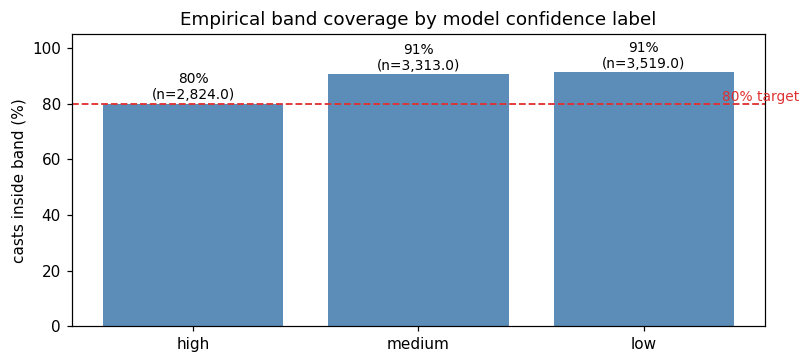

In [3]:
by_lab = j.groupby("confidence_label").agg(
    n=("inside", "size"), coverage=("inside", "mean")).reindex(
    ["high", "medium", "low"])
by_src = j.assign(src=np.where(j.site_code.str.startswith("CF"),
    "ONC CF", "DFO")).groupby("src").agg(
    n=("inside", "size"), coverage=("inside", "mean"))
fig, ax = plt.subplots(figsize=(7.5, 3.4), dpi=110)
bars = ax.bar(by_lab.index, by_lab.coverage * 100, color="#5b8db8")
ax.axhline(80, ls="--", color="#e03131", lw=1.2)
ax.text(2.35, 81, "80% target", color="#e03131", fontsize=9)
for b, (_, r) in zip(bars, by_lab.iterrows()):
    ax.text(b.get_x() + b.get_width() / 2, r.coverage * 100 + 1.5,
            f"{r.coverage:.0%}\n(n={r.n:,})", ha="center", fontsize=9)
ax.set(ylim=(0, 105), ylabel="casts inside band (%)",
       title="Empirical band coverage by model confidence label")
plt.tight_layout()
print(by_src.round(3))
print("RESULT by_label=" + ", ".join(
    f"{i}:{r.coverage:.1%}(n={r.n})" for i, r in by_lab.iterrows()))

## Reading the result

Coverage at or a little above 80% on this in-sample check is what a well-calibrated (slightly conservative) product should show; materially *below* 80% here would flag a problem, since held-out coverage is typically lower still. Per-label numbers show whether the `confidence_label` column is informative: bands at `high`-confidence stations should cover at least as well as `low` ones.

Every number above regenerates from the committed inputs with `jupyter nbconvert --execute` — that, plus the 92-check UI suite in `scripts/test_dashboard.js`, is this project's definition of reproducible.